
# CSI-6-ARI Week 6 Tutorial - Complete Solution

## Supervised Learning (Classification) and Unsupervised Learning

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/gene_expression.csv')
print(df.head())
df = pd.read_csv('data/gene_expression.csv')print(df.shape, df['Cancer Present'].value_counts())

   Gene One  Gene Two  Cancer Present
0       4.3       3.9               1
1       2.5       6.3               0
2       5.7       3.9               1
3       6.1       6.2               0
4       7.4       3.4               1
(3000, 3) Cancer Present
1    1500
0    1500
Name: count, dtype: int64


In [5]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


In [6]:
df = pd.read_csv('data/gene_expression.csv')

In [4]:
from sklearn.model_selection import train_test_split

X = df[['Gene One', 'Gene Two']]
y = df['Cancer Present']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Set the default plot size for seaborn/matplotlib figures.

<Axes: xlabel='Gene One', ylabel='Gene Two'>

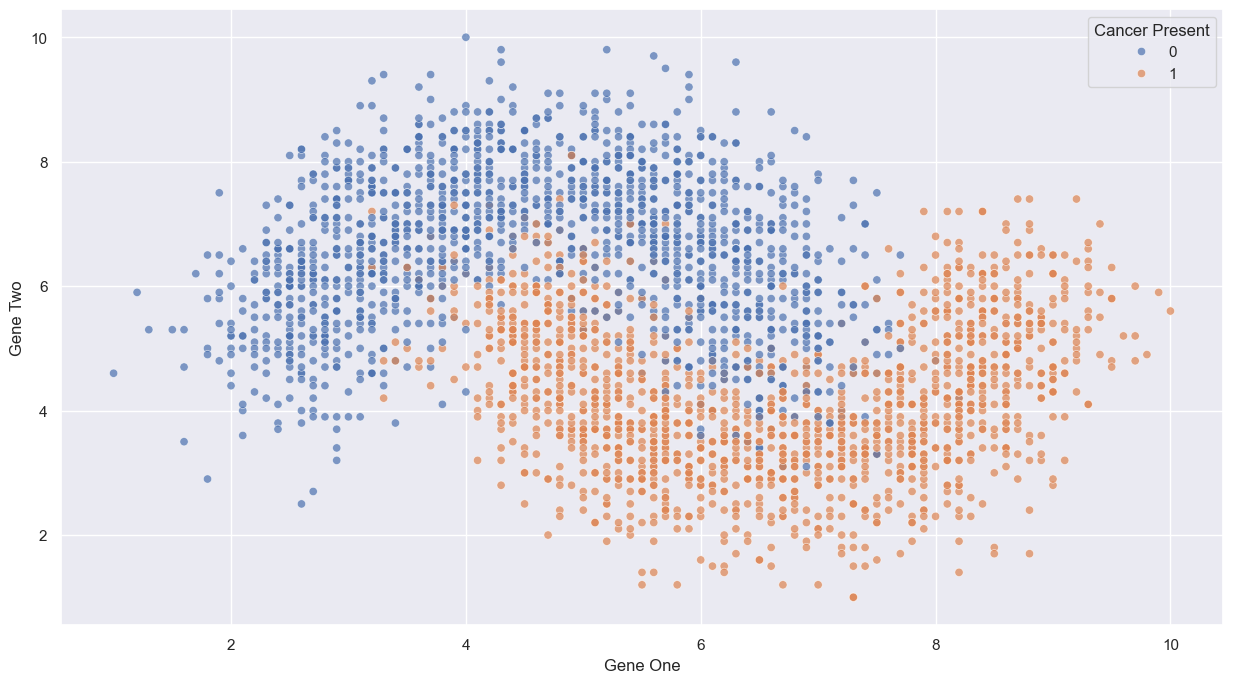

In [7]:
# Set the default plot size for seaborn/matplotlib figures.
# This makes the scatter plot easier to read (especially labels and class separation).
sns.set(rc={'figure.figsize': (15, 8)})

# Visualise the dataset in 2D using the two gene-expression features.
# Each point is one patient/sample, the colour (hue) shows the class label: whether cancer is present.
# alpha adds transparency so overlapping points are easier to see (reveals density).
sns.scatterplot(x='Gene One', y='Gene Two', hue='Cancer Present', data=df, alpha=0.7)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform on training data only — learns mean & std from train
X_train_scaled = scaler.fit_transform(X_train)

# transform only on test — uses the training mean & std
X_test_scaled  = scaler.transform(X_test)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_scaled, y_train)
pred1 = knn1.predict(X_test_scaled)
print(accuracy_score(y_test, pred1))

0.8944444444444445


0.8944444444444445


Text(0, 0.5, 'Error Rate')

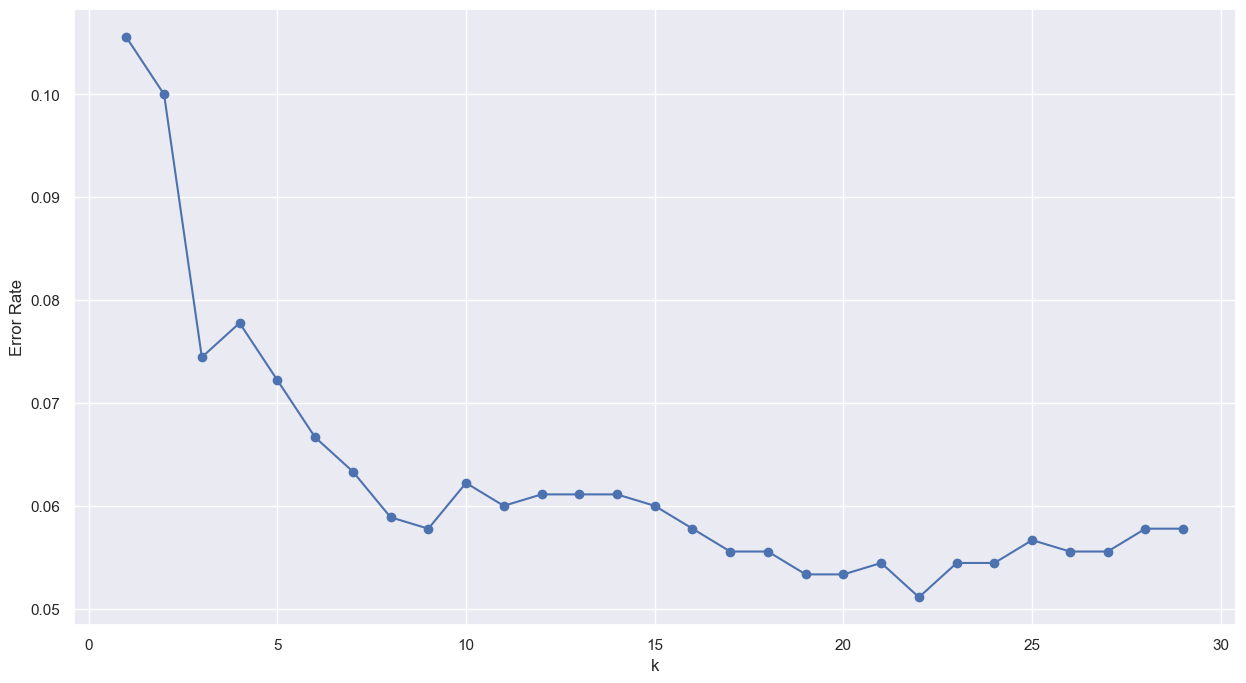

In [12]:
error_rates = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    err = 1 - accuracy_score(y_test, knn.predict(X_test_scaled))
    error_rates.append(err)

plt.plot(range(1,30), error_rates, marker='o')
plt.xlabel('k'); plt.ylabel('Error Rate')

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Pipeline: scaler then KNN
# Scaler fits only on each CV fold's training split — no leakage
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier())
])

param_grid = {'knn__n_neighbors': list(range(1, 30))}

full_cv = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
full_cv.fit(X_train, y_train)   # unscaled X_train — pipeline handles scaling

print(full_cv.best_params_, full_cv.best_score_)

{'knn__n_neighbors': 20} 0.9304761904761906


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = full_cv.best_estimator_.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9466666666666667
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       470
           1       0.95      0.93      0.94       430

    accuracy                           0.95       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.95      0.95      0.95       900



In [15]:
df_sn = pd.read_csv('data/Social_Network_Ads.csv')
# Features: Age, EstimatedSalary  |  Target: Purchased (0/1)

X_sn = df_sn[['Age', 'EstimatedSalary']]
y_sn = df_sn['Purchased']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sn, y_sn, test_size=0.25, random_state=42
)

pipe_sn = Pipeline([('sc', StandardScaler()), ('knn', KNeighborsClassifier())])
gs_sn = GridSearchCV(pipe_sn, {'knn__n_neighbors': range(1,20)}, cv=5)
gs_sn.fit(X_tr, y_tr)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': range(1, 20)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [17]:
from sklearn.cluster import KMeans

df_m = pd.read_csv('data/Mall_Customers.csv')
X_m = df_m[['Annual Income (k$)', 'Spending Score (1-100)']]

sc = StandardScaler()
X_scaled = sc.fit_transform(X_m)

inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

In [18]:
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df_m['Cluster'] = km5.fit_predict(X_scaled)

print(df_m.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())


         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [20]:
df_sn = pd.read_csv('data/Social_Network_Ads.csv')
# Features: Age, EstimatedSalary  |  Target: Purchased (0/1)

X_sn = df_sn[['Age', 'EstimatedSalary']]
y_sn = df_sn['Purchased']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sn, y_sn, test_size=0.25, random_state=42
)

pipe_sn = Pipeline([('sc', StandardScaler()), ('knn', KNeighborsClassifier())])
gs_sn = GridSearchCV(pipe_sn, {'knn__n_neighbors': range(1,20)}, cv=5)
gs_sn.fit(X_tr, y_tr)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': range(1, 20)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


# Exercise 1 — Bank Marketing Clustering

In [23]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

df_bank = pd.read_csv('data/bank-full.csv')

num_cols = ['age', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx',
            'cons.conf.idx', 'euribor3m', 'nr.employed']
cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'month', 'poutcome']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                              num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_bank = preprocessor.fit_transform(df_bank[num_cols + cat_cols])

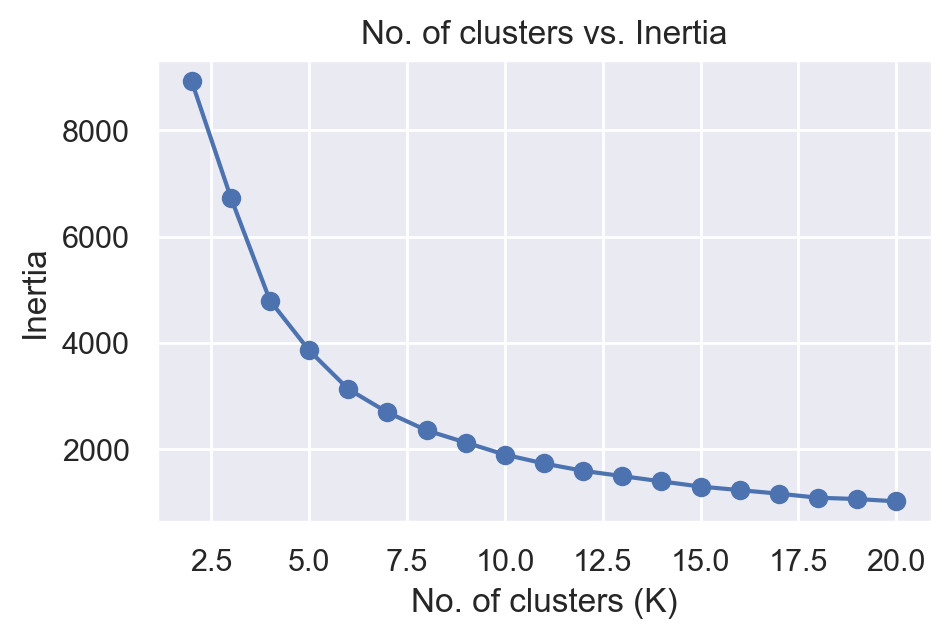

In [25]:
options = range(2,21)
inertias = []

for n_clusters in options:
    model = KMeans(n_clusters, random_state=42).fit(X)
    inertias.append(model.inertia_)
plt.figure(figsize=(5,3),dpi=200)
plt.title("No. of clusters vs. Inertia")
plt.plot(options, inertias, '-o')
plt.xlabel('No. of clusters (K)')
plt.ylabel('Inertia');

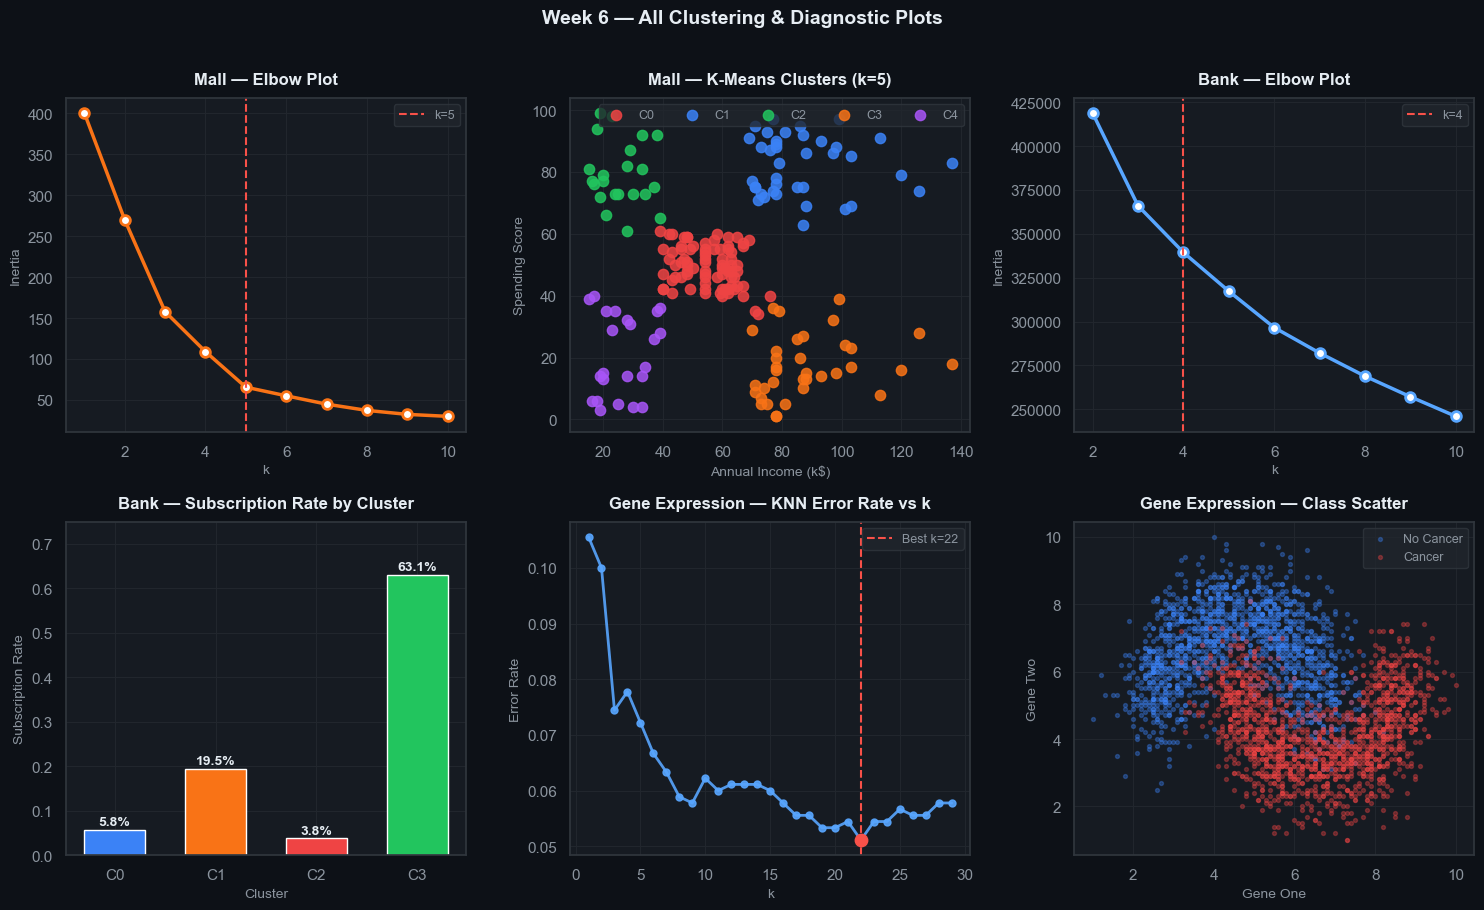

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ---- Load data ----
df_mall = pd.read_csv('data/Mall_Customers.csv')
df_bank = pd.read_csv('data/bank-full.csv')
df_gene = pd.read_csv('data/gene_expression.csv')

# ---- Mall K-Means ----
X_mall = df_mall[['Annual Income (k$)', 'Spending Score (1-100)']]
X_ms = StandardScaler().fit_transform(X_mall)
iner_m = [KMeans(k, random_state=42, n_init=10).fit(X_ms).inertia_ for k in range(1, 11)]
df_mall['Cluster'] = KMeans(5, random_state=42, n_init=10).fit_predict(X_ms)

# ---- Bank K-Means ----
num_b = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
         'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
cat_b = ['job', 'marital', 'education', 'default', 'housing',
         'loan', 'contact', 'month', 'poutcome']
pre_b = ColumnTransformer([
    ('n', StandardScaler(), num_b),
    ('c', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_b)
])
Xbp = pre_b.fit_transform(df_bank[num_b + cat_b])
iner_b = [KMeans(k, random_state=42, n_init=5, max_iter=100).fit(Xbp).inertia_
          for k in range(2, 11)]
df_bank['Cluster'] = KMeans(4, random_state=42, n_init=10).fit_predict(Xbp)
sub_rate = df_bank.groupby('Cluster')['subscribed'].apply(lambda x: (x == 'yes').mean())

# ---- Gene KNN error rate ----
X_g = df_gene[['Gene One', 'Gene Two']]; y_g = df_gene['Cancer Present']
Xtr, Xte, ytr, yte = train_test_split(X_g, y_g, test_size=0.3, random_state=42)
sc_g = StandardScaler(); Xtr_s = sc_g.fit_transform(Xtr); Xte_s = sc_g.transform(Xte)
err = [1 - accuracy_score(yte, KNeighborsClassifier(n_neighbors=k).fit(Xtr_s, ytr).predict(Xte_s))
       for k in range(1, 30)]

# ---- Plot ----
colors_c = ['#ef4444', '#3b82f6', '#22c55e', '#f97316', '#a855f7']
bank_c   = ['#3b82f6', '#f97316', '#ef4444', '#22c55e']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor('#0d1117')

def style(ax, title, xlabel, ylabel):
    ax.set_facecolor('#161b22')
    ax.set_title(title, color='#e6edf3', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, color='#8b949e', fontsize=10)
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=10)
    ax.tick_params(colors='#8b949e')
    for s in ax.spines.values(): s.set_edgecolor('#30363d')
    ax.grid(color='#21262d', linewidth=0.8)

# 1) Mall Elbow
axes[0,0].plot(range(1,11), iner_m, 'o-', color='#f97316', lw=2.5, ms=7, mfc='white', mew=2)
axes[0,0].axvline(5, color='#f85149', ls='--', lw=1.5, label='k=5')
style(axes[0,0], 'Mall — Elbow Plot', 'k', 'Inertia')
axes[0,0].legend(fontsize=9, labelcolor='#8b949e', facecolor='#21262d', edgecolor='#30363d')

# 2) Mall Cluster Scatter
for c in range(5):
    m = df_mall['Cluster'] == c
    axes[0,1].scatter(df_mall.loc[m,'Annual Income (k$)'],
                      df_mall.loc[m,'Spending Score (1-100)'],
                      color=colors_c[c], s=55, alpha=0.85, label=f'C{c}')
style(axes[0,1], 'Mall — K-Means Clusters (k=5)', 'Annual Income (k$)', 'Spending Score')
axes[0,1].legend(fontsize=9, labelcolor='#8b949e', facecolor='#21262d', edgecolor='#30363d', ncol=5)

# 3) Bank Elbow
axes[0,2].plot(range(2,11), iner_b, 'o-', color='#58a6ff', lw=2.5, ms=7, mfc='white', mew=2)
axes[0,2].axvline(4, color='#f85149', ls='--', lw=1.5, label='k=4')
style(axes[0,2], 'Bank — Elbow Plot', 'k', 'Inertia')
axes[0,2].legend(fontsize=9, labelcolor='#8b949e', facecolor='#21262d', edgecolor='#30363d')

# 4) Bank Subscription Rate
axes[1,0].bar(range(4), sub_rate.values, color=bank_c, width=0.6)
for i, v in enumerate(sub_rate.values):
    axes[1,0].text(i, v + 0.01, f'{v:.1%}', ha='center', color='#e6edf3', fontsize=10, fontweight='bold')
axes[1,0].set_ylim(0, 0.75)
axes[1,0].set_xticks(range(4))
axes[1,0].set_xticklabels(['C0', 'C1', 'C2', 'C3'])
style(axes[1,0], 'Bank — Subscription Rate by Cluster', 'Cluster', 'Subscription Rate')

# 5) KNN Error Rate vs k
axes[1,1].plot(range(1,30), err, 'o-', color='#58a6ff', lw=2, ms=5, alpha=0.9)
axes[1,1].axvline(22, color='#f85149', ls='--', lw=1.5, label='Best k=22')
axes[1,1].scatter([22], [err[21]], color='#f85149', s=80, zorder=5)
style(axes[1,1], 'Gene Expression — KNN Error Rate vs k', 'k', 'Error Rate')
axes[1,1].legend(fontsize=9, labelcolor='#8b949e', facecolor='#21262d', edgecolor='#30363d')

# 6) Gene scatter
axes[1,2].scatter(df_gene[y_g==0]['Gene One'], df_gene[y_g==0]['Gene Two'],
                  color='#3b82f6', s=8, alpha=0.35, label='No Cancer')
axes[1,2].scatter(df_gene[y_g==1]['Gene One'], df_gene[y_g==1]['Gene Two'],
                  color='#ef4444', s=8, alpha=0.35, label='Cancer')
style(axes[1,2], 'Gene Expression — Class Scatter', 'Gene One', 'Gene Two')
axes[1,2].legend(fontsize=9, labelcolor='#8b949e', facecolor='#21262d', edgecolor='#30363d')

plt.suptitle('Week 6 — All Clustering & Diagnostic Plots',
             color='#e6edf3', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_plots.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()